In [11]:
#Cell 1
!pip install opencv-python-headless -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

print(f"OpenCV : {cv2.__version__}")
print("Imports: OK")



OpenCV : 4.14.0
Imports: OK


In [2]:
#Cell 2
def capture_from_webcam(filename="my_photo.jpg"):
    js = Javascript("""
        async function capturePhoto() {

            // ---- Build the on-screen widget ----
            const wrapper = document.createElement("div");
            wrapper.style.cssText =
                "text-align:center; padding:20px; background:#1a1a1a;" +
                "border-radius:12px; font-family:sans-serif;";

            const title = document.createElement("h3");
            title.textContent = "Webcam Capture";
            title.style.color = "#eeeeee";

            // Video element shows live webcam preview
            const video = document.createElement("video");
            video.style.cssText =
                "width:480px; border-radius:10px; border:3px solid #4CAF50;" +
                "display:block; margin:10px auto;";
            video.autoplay = true;
            video.playsinline = true;

            const btn = document.createElement("button");
            btn.textContent = "Capture Photo";
            btn.style.cssText =
                "padding:12px 30px; font-size:15px; background:#4CAF50;" +
                "color:white; border:none; border-radius:6px; cursor:pointer; margin-top:10px;";

            wrapper.appendChild(title);
            wrapper.appendChild(video);
            wrapper.appendChild(btn);
            document.body.appendChild(wrapper);

            // ---- Start webcam stream ----
            const stream = await navigator.mediaDevices.getUserMedia(
                {video: {width: 640, height: 480}}
            );
            video.srcObject = stream;
            await video.play();

            // Expand Colab output area to fit the widget
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // ---- Wait for the user to click Capture ----
            await new Promise(resolve => { btn.onclick = resolve; });

            // ---- Grab the current video frame ----
            const canvas = document.createElement("canvas");
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext("2d").drawImage(video, 0, 0);

            // Stop all webcam tracks so the browser camera light turns off
            stream.getTracks().forEach(track => track.stop());
            wrapper.remove();

            // Return frame as base64 JPEG (quality 0.95)
            return canvas.toDataURL("image/jpeg", 0.95);
        }
    """)
    display(js)

    # eval_js runs capturePhoto() in the browser and returns the base64 string to Python
    data = eval_js("capturePhoto()")

    # Strip the data-URI prefix  e.g. "data:image/jpeg;base64,<payload>"
    img_bytes = b64decode(data.split(",")[1])

    with open(filename, "wb") as f:
        f.write(img_bytes)

    print(f"Saved: {filename}")
    return filename

In [4]:
#Cell 3
# Run this cell -> webcam widget opens in the output area below
# Position yourself and click the green "Capture Photo" button

img_path = capture_from_webcam("my_photo.jpg")

<IPython.core.display.Javascript object>

Saved: my_photo.jpg


Resolution ; 640 x 480 pixels
Channels : 3 (Blue, Green, Red)
dtype : uint8


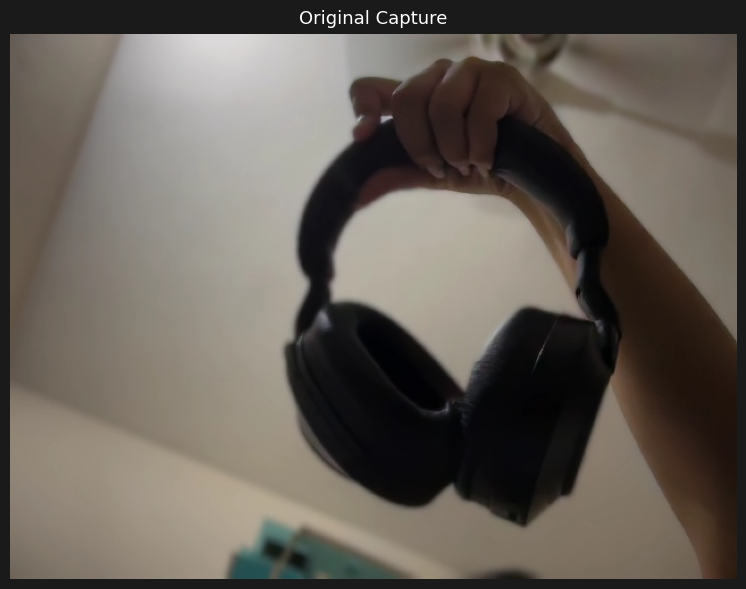

In [12]:
#Cell 4.1 - 4.2
def show_bgr(img,title="", figsize=(9,6), cmap= None):
  fig, ax= plt.subplots(figsize= figsize)
  fig.patch.set_facecolor("#1a1a1a")
  ax.set_facecolor('#1a1a1a')

  if len(img.shape)== 3:
   ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  else:
   ax.imshow(img, cmap= cmap or "gray")

  ax.set_title(title, color="white", fontsize=13, pad=8)
  ax.axis("off")
  plt.tight_layout()

original = cv2.imread(img_path)
print(f"Resolution ; {original.shape[1]} x {original.shape[0]} pixels")
print(f"Channels : {original.shape[2]} (Blue, Green, Red)")
print(f"dtype : {original.dtype}")

show_bgr(original, "Original Capture")



In [13]:
#cell 5
def cartoon_effect(img):
    smoothed = img.copy()
    for _ in range(5):
        smoothed = cv2.bilateralFilter(smoothed, d=9, sigmaColor=250, sigmaSpace=250)

    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.medianBlur(gray, 7)

    edges = cv2.adaptiveThreshold(
        gray_blur, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        blockSize=9, C=2
    )

    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    return cv2.bitwise_and(smoothed, edges_bgr)


def pencil_sketch(img):
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    inverted = cv2.bitwise_not(gray)
    blurred  = cv2.GaussianBlur(inverted, ksize=(21, 21), sigmaX=0)

    sketch   = cv2.divide(gray, 255 - blurred, scale=256.0)
    return sketch


def thermal_vision(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.applyColorMap(gray, cv2.COLORMAP_INFERNO)


def neon_glow(img):
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1=80, threshold2=180)

    inv_edges = cv2.bitwise_not(edges)

    dist = cv2.distanceTransform(inv_edges, cv2.DIST_L2, 3)

    cv2.normalize(dist, dist, 0, 255, cv2.NORM_MINMAX)
    gradient_img = np.uint8(dist)

    neon = cv2.applyColorMap(gradient_img, cv2.COLORMAP_HSV)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thick = cv2.dilate(edges, kernel, iterations=2)
    neon_glow = cv2.bitwise_and(neon, neon, mask=thick)

    return cv2.GaussianBlur(neon_glow, (9, 9), sigmaX=2)


def pixelate(img, block_size=8):
    h, w   = img.shape[:2]
    small  = cv2.resize(img, (w // block_size, h // block_size),
                        interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)


def emboss_effect(img):
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ], dtype=np.float32)

    result = cv2.filter2D(gray.astype(np.float32), ddepth=cv2.CV_32F, kernel=kernel)
    return np.clip(result + 128, 0, 255).astype(np.uint8)


print("All 6 effect functions defined.")

All 6 effect functions defined.


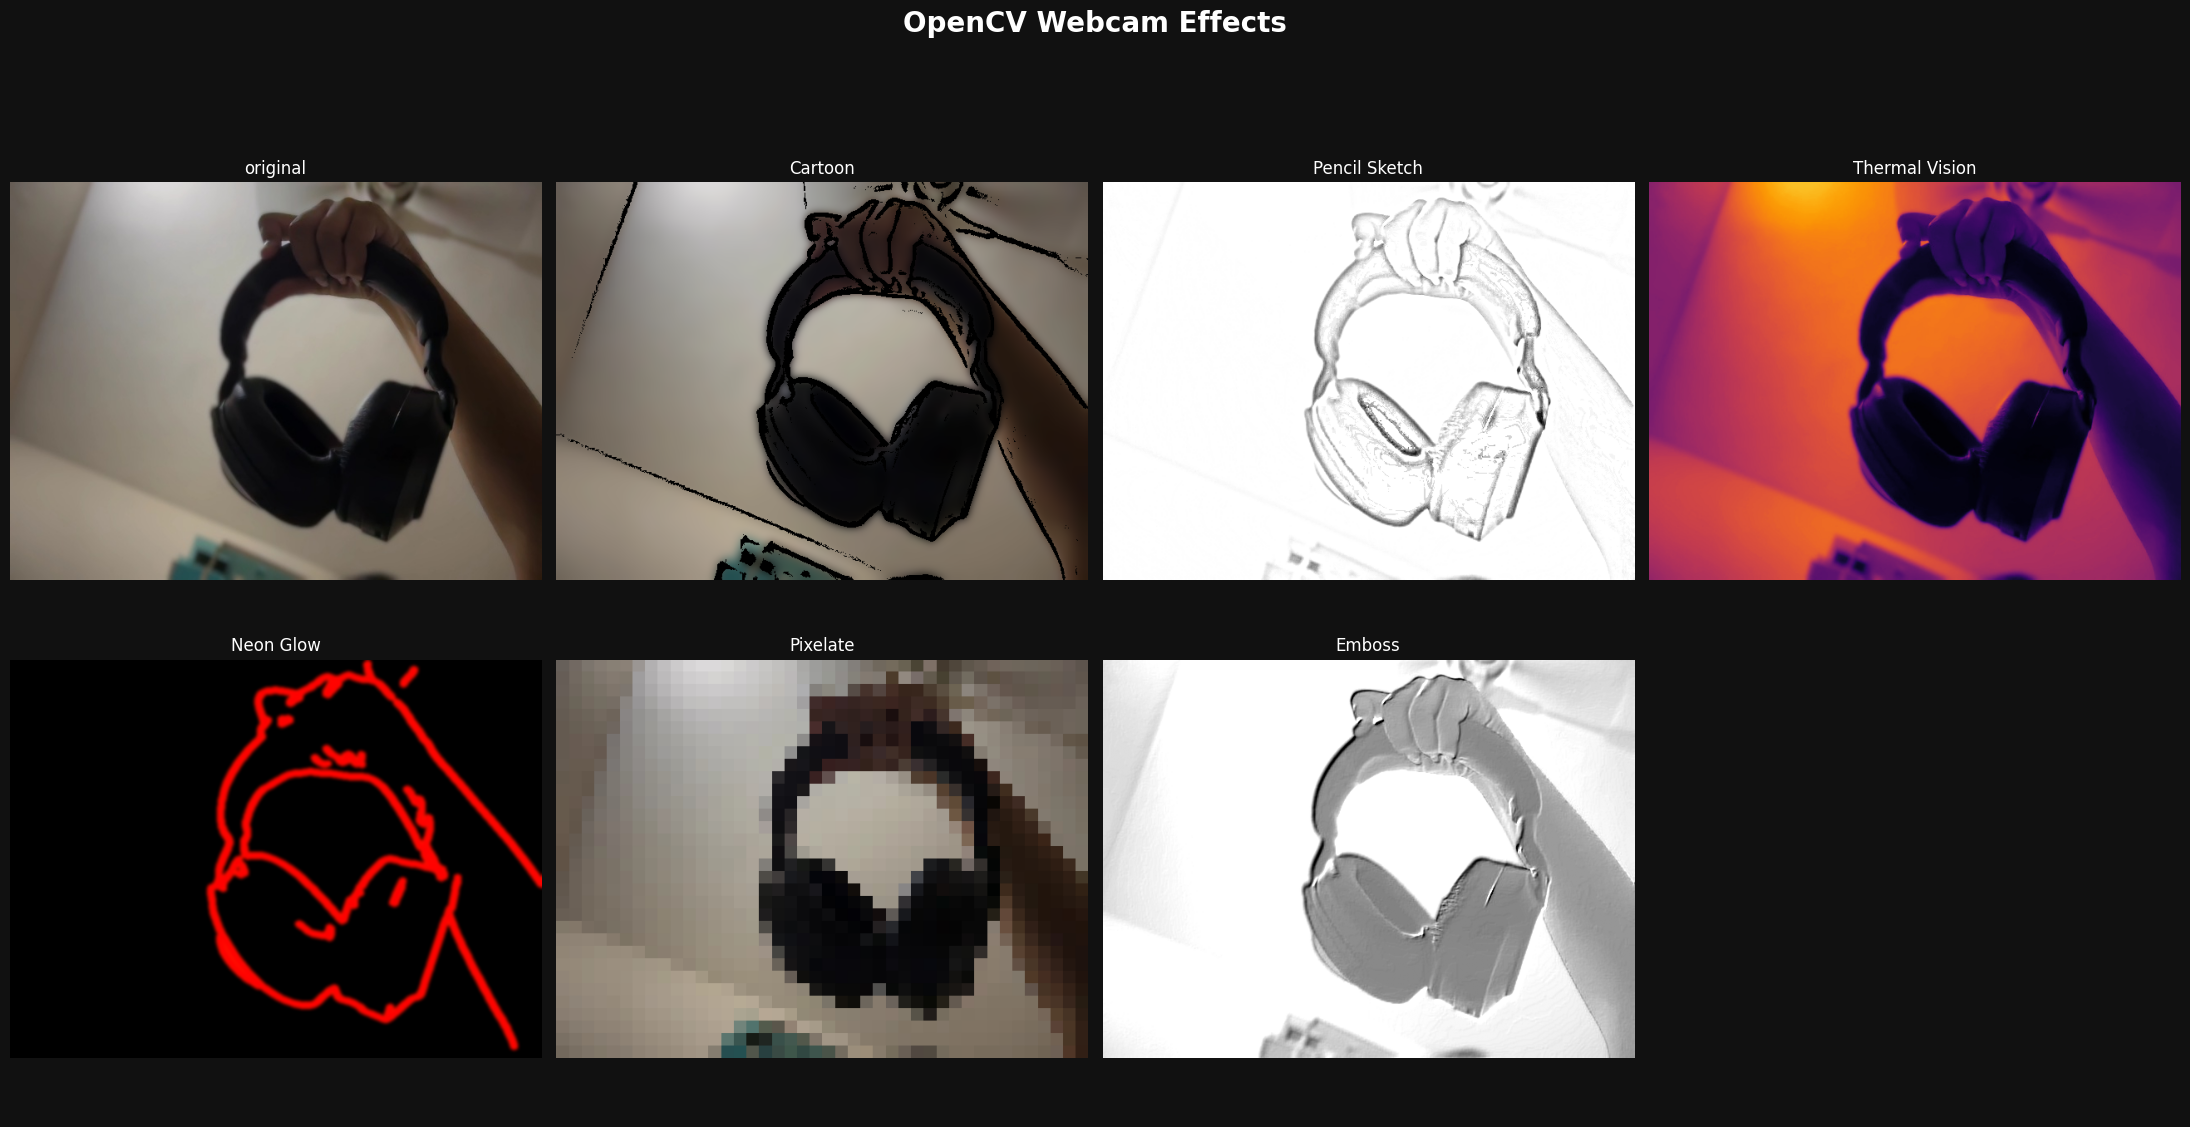

Grid saved: effects_grid.jpg


In [14]:
#cell 6.1 - 6.3
effects = {
"original": cv2.cvtColor(original, cv2.COLOR_BGR2RGB),
"Cartoon": cv2.cvtColor(cartoon_effect(original), cv2.COLOR_BGR2RGB),
"Pencil Sketch": pencil_sketch(original), #grayscale
"Thermal Vision": cv2.cvtColor(thermal_vision(original), cv2.COLOR_BGR2RGB),
"Neon Glow": cv2.cvtColor(neon_glow(original), cv2.COLOR_BGR2RGB),
"Pixelate": cv2.cvtColor(pixelate(original, block_size=15), cv2.COLOR_BGR2RGB),
"Emboss": emboss_effect(original), #grayscale
}

fig, axes = plt.subplots(2,4, figsize = (22,11))
fig.patch.set_facecolor("#111111")
fig.suptitle("OpenCV Webcam Effects", color="White", fontsize=20, fontweight= "bold", y=1.02)

for idx, (name, img) in enumerate(effects.items()):
    row, col = divmod(idx, 4)        # maps idx 0-6 to (row, col) in 2x4 grid
    ax = axes[row][col]
    ax.set_facecolor("#111111")

    if len(img.shape) == 2:          # grayscale image -> apply gray colormap
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)

    ax.set_title(name, color="white", fontsize=12, pad=6)
    ax.axis("off")

ax.set_title(name, color="white", fontsize= 12, pad=6)
ax.axis('off')

#hide unused 8th subplot cleanly

axes[1][3]. axis('off')
axes[1][3]. set_facecolor("#111111")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('effects_grid.jpg', dpi=150, bbox_inches= 'tight', facecolor="#111111")
plt.show()
print("Grid saved: effects_grid.jpg")

Detected: 0 face(s)


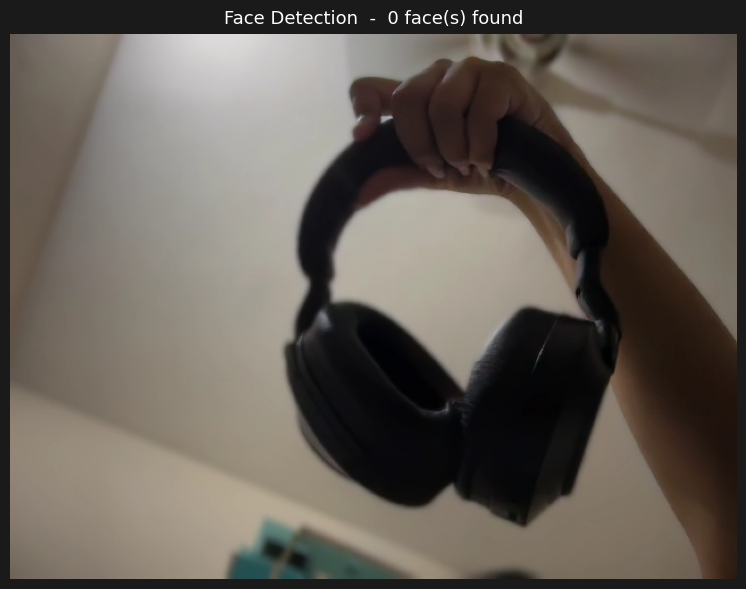

In [15]:
#cell 7
def detect_faces(img):
    xml_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    cascade  = cv2.CascadeClassifier(xml_path)

    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)   # normalize brightness -> better detection in uneven light

    faces = cascade.detectMultiScale(
        gray_eq, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50)
    )

    output = img.copy()
    for (x, y, w, h) in faces:
        # Green rectangle around each detected face
        cv2.rectangle(output, (x, y), (x + w, y + h), color=(0, 220, 0), thickness=2)
        # Label placed just above the rectangle
        cv2.putText(output, "Face", org=(x, y - 10),
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.7,
                    color=(0, 220, 0), thickness=2)

    return output, len(faces)


face_output, n = detect_faces(original)
print(f"Detected: {n} face(s)")
show_bgr(face_output, f"Face Detection  -  {n} face(s) found")

In [ ]:
#cell 8

